In [1]:
import pandas as pd

X = pd.read_csv("../data/X_train_6ZIKlTY.csv")
Y = pd.read_csv("../data/y_train_lXj6X5y.csv")

eda = X.merge(Y, on="Index", validate="one_to_one")

Visits per patient:
 count    5576.000000
mean        7.966643
std         3.507066
min         4.000000
25%         4.000000
50%         7.000000
75%        12.000000
max        12.000000
dtype: float64
Target by cohort:
           count       mean        std  min   25%   50%    75%    max
cohort                                                              
A       39527.0  37.806087  16.653480  0.0  25.8  37.8  49.90  109.5
B        4895.0  33.628682  15.024723  0.0  23.2  33.3  43.45   85.1
Missing % by cohort:
         Index  patient_id  sexM  gene  age_at_diagnosis  age  ledd  \
cohort                                                               
A         0.0         0.0   0.0  30.8               4.9  0.0  36.5   
B         0.0         0.0   0.0  42.5               5.5  0.0  42.7   

        time_since_intake_on  time_since_intake_off    on   off  target  \
cohort                                                                    
A                       46.2                   7

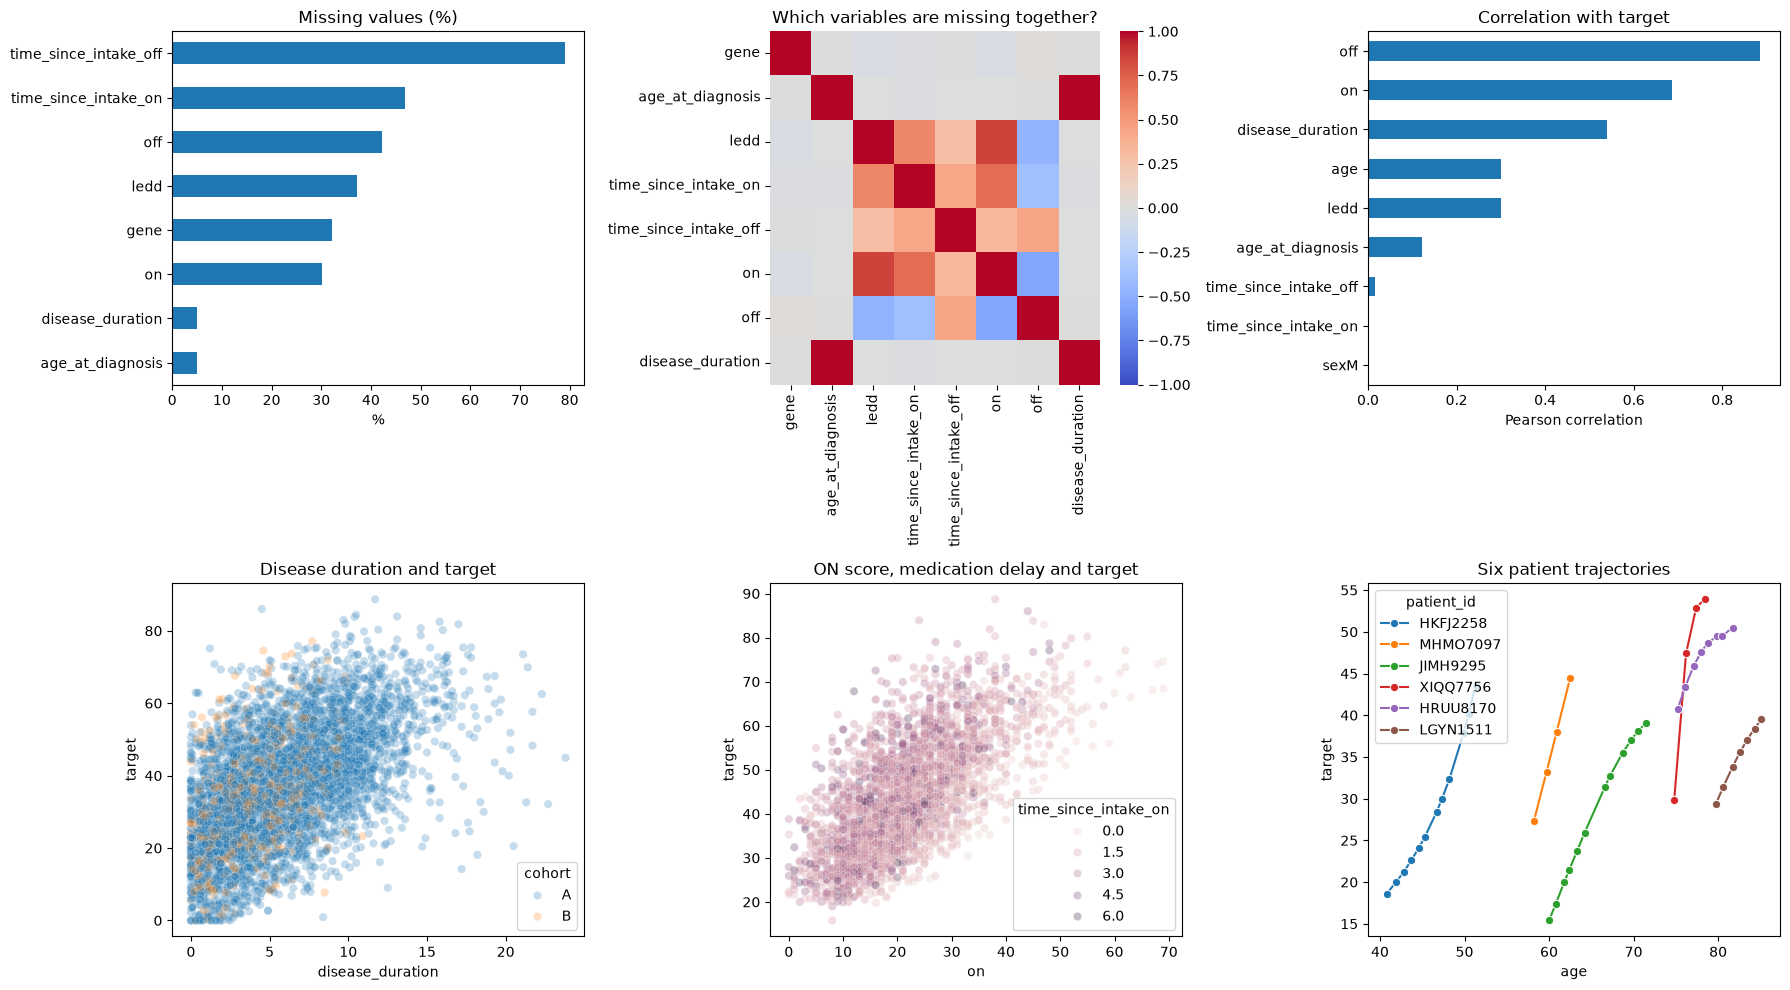

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

X = pd.read_csv("../data/X_train_6ZIKlTY.csv")
Y = pd.read_csv("../data/y_train_lXj6X5y.csv")
split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, _ = next(split.split(X, groups=X["patient_id"]))
eda = X.iloc[train_idx].merge(Y, on="Index", validate="one_to_one")
eda["disease_duration"] = eda["age"] - eda["age_at_diagnosis"]

print("Visits per patient:\n", eda.groupby("patient_id").size().describe())
print("Target by cohort:\n", eda.groupby("cohort")["target"].describe())
print("Missing % by cohort:\n", eda.groupby("cohort").agg(
    lambda col: 100 * col.isna().mean()).round(1))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

missing = eda.columns[eda.isna().any()]
(100 * eda[missing].isna().mean()).sort_values().plot.barh(ax=axes[0, 0])
axes[0, 0].set(title="Missing values (%)", xlabel="%")

sns.heatmap(eda[missing].isna().corr(), vmin=-1, vmax=1,
            cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Which variables are missing together?")

numeric = eda.select_dtypes("number").drop(columns=["Index"])
numeric.corr()["target"].drop("target").sort_values().plot.barh(ax=axes[0, 2])
axes[0, 2].set(title="Correlation with target", xlabel="Pearson correlation")

sample = eda.sample(min(5000, len(eda)), random_state=42)
sns.scatterplot(data=sample, x="disease_duration", y="target",
                hue="cohort", alpha=0.25, ax=axes[1, 0])
axes[1, 0].set_title("Disease duration and target")

sns.scatterplot(data=sample, x="on", y="target",
                hue="time_since_intake_on", alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title("ON score, medication delay and target")

patients = eda["patient_id"].drop_duplicates().sample(6, random_state=42)
history = eda[eda["patient_id"].isin(patients)].sort_values("age")
sns.lineplot(data=history, x="age", y="target", hue="patient_id",
             estimator=None, marker="o", ax=axes[1, 2])
axes[1, 2].set_title("Six patient trajectories")

plt.tight_layout()
plt.show()